# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


- **Project link**: https://www.kaggle.com/datasets/uciml/mushroom-classification/data
- **Challenge description**: The inspiration for this dataset is to determine what types of machine learning models perform best on this dataset and which features are most indicative of a poisonous mushroom. The context of the dataset stems from 23 species of gilled mushrooms in the Agaricus and Lepiota Family Mushroom drawn from The Audubon Society Field Guide to North American Mushrooms. Each mushroom species is identified as either edible, poisonous, or unknown edibility.
- **Data description**: The mushroom classification dataset has 23 columns, consisting of the mushroom classes and physical features such as mushroom cap shape and cap surface. Each datapoint contains either a letter or a '?'. The letter corresponds to the features the mushroom has and the '?' indicates missing information.

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Loading the data / Counting the number of rows (data points) and features / looking for any missing values

In [1]:
import pandas as pd

# Load data
df = pd.read_csv("mushrooms.csv")

# Shape
print("Data Shape:")
print("Rows, Columns:", df.shape)

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Preview
print("\nData Head:")
df.head()

Data Shape:
Rows, Columns: (8124, 23)

Missing values per column:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Data Head:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## Feature Summmary

In [2]:
## making tables (feature summary)
summary = []

for col in df.columns:
    unique_vals = df[col].unique()
    summary.append({
        "Feature": col,
        "Type": "Categorical",
        "Unique Values": unique_vals[:5],
        "Num Unique": len(unique_vals),
        "Missing": df[col].isnull().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Feature,Type,Unique Values,Num Unique,Missing
0,class,Categorical,"[p, e]",2,0
1,cap-shape,Categorical,"[x, b, s, f, k]",6,0
2,cap-surface,Categorical,"[s, y, f, g]",4,0
3,cap-color,Categorical,"[n, y, w, g, e]",10,0
4,bruises,Categorical,"[t, f]",2,0
5,odor,Categorical,"[p, a, l, n, f]",9,0
6,gill-attachment,Categorical,"[f, a]",2,0
7,gill-spacing,Categorical,"[c, w]",2,0
8,gill-size,Categorical,"[n, b]",2,0
9,gill-color,Categorical,"[k, n, g, p, w]",12,0


**Explanation**:
- No missing values (note: '?' appears in stalk-root). According to the Kaggle challenge, '?' is assigned to as missing.

## Outliers
- **Definition**: Data points that significantly differ from other observations in the dataset. Methods used to detect outliers is the interquartile range (IQR) or z-score.
- In this dataset, outliers are not applicable because the dataset is categorical only. Outliers are usually used for numerical data.

## Any class imbalance?

In [3]:
print(df['class'].value_counts())

class
e    4208
p    3916
Name: count, dtype: int64


In [4]:
print(df['class'].value_counts(normalize=True))

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64


**class imbalance explanation**: The dataset doesn't seem to have a class imbalance. The dataset seems balanced.

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

In [5]:
import matplotlib.pyplot as plt

# Encode target for plotting
df['class'] = df['class'].map({'e': 0, 'p': 1})

## Target
- Feature: class
- Encoding:
e = 0
p = 1

Target variable "class": 0 = edible, 1 = poisonous

<Figure size 600x400 with 0 Axes>

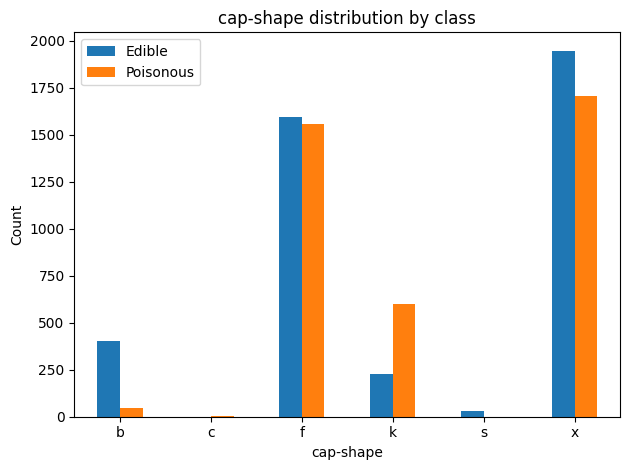

<Figure size 600x400 with 0 Axes>

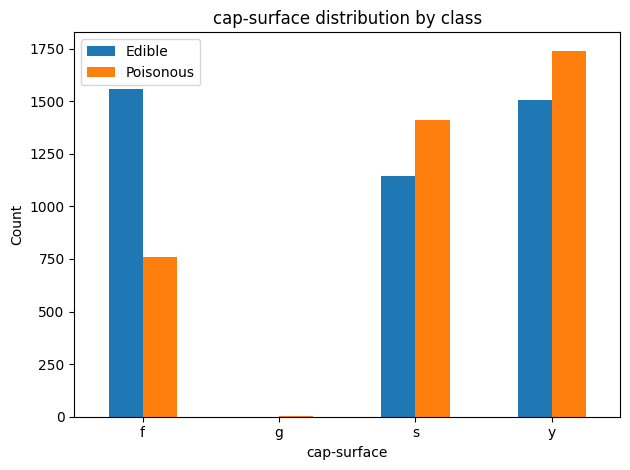

<Figure size 600x400 with 0 Axes>

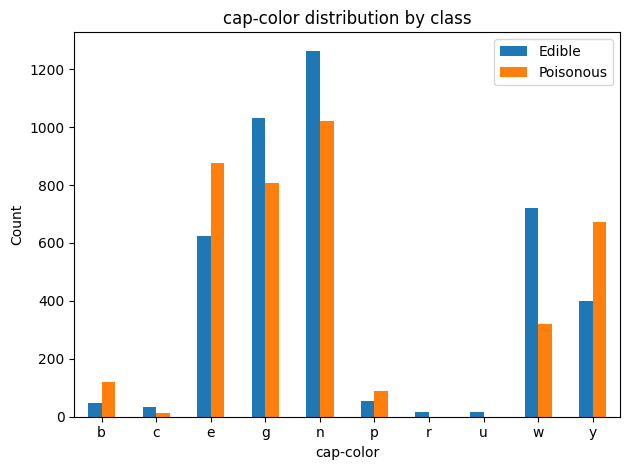

<Figure size 600x400 with 0 Axes>

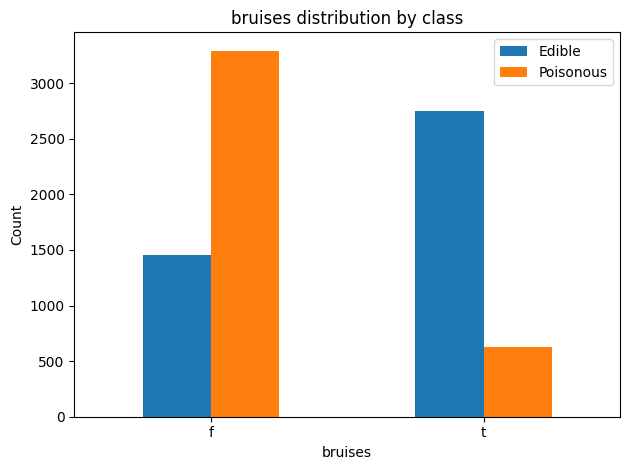

<Figure size 600x400 with 0 Axes>

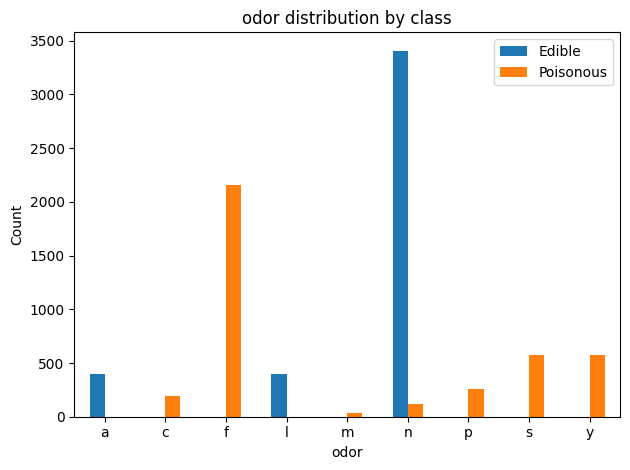

<Figure size 600x400 with 0 Axes>

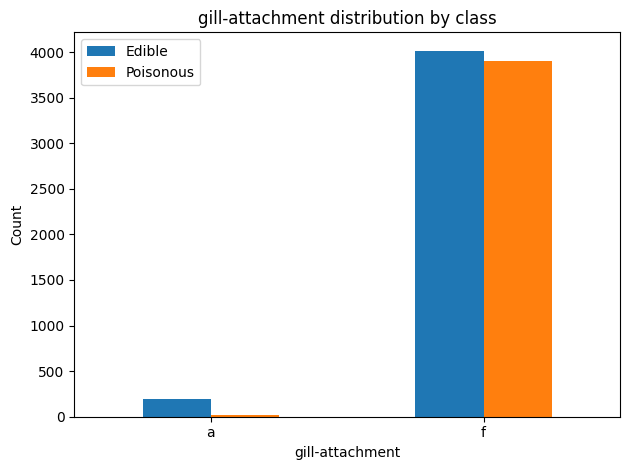

<Figure size 600x400 with 0 Axes>

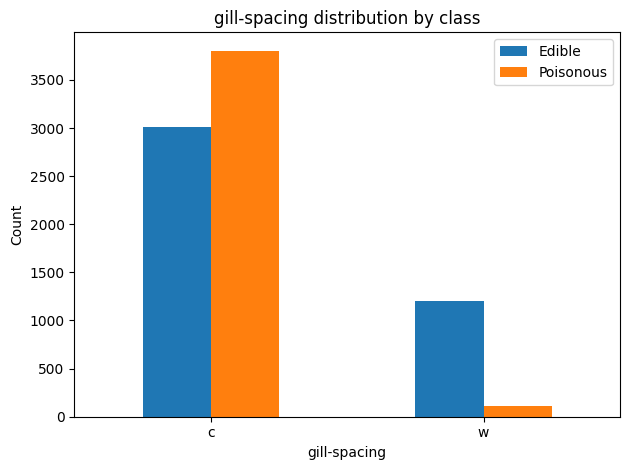

<Figure size 600x400 with 0 Axes>

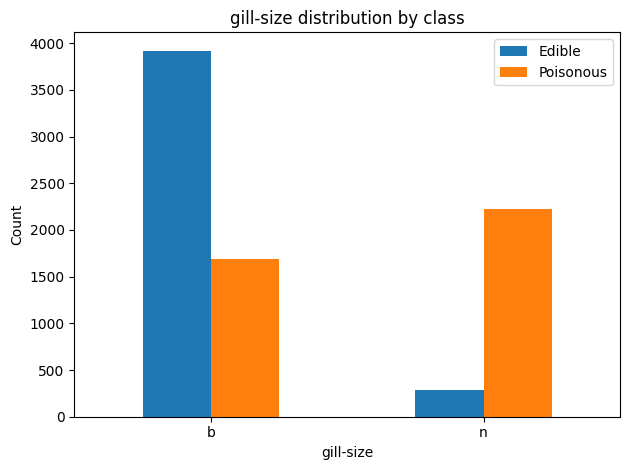

<Figure size 600x400 with 0 Axes>

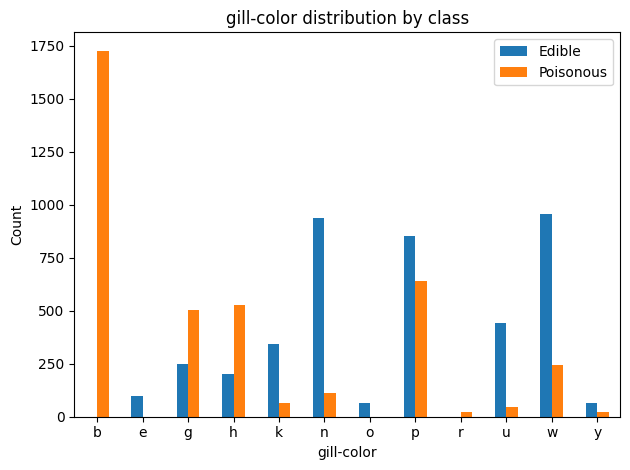

<Figure size 600x400 with 0 Axes>

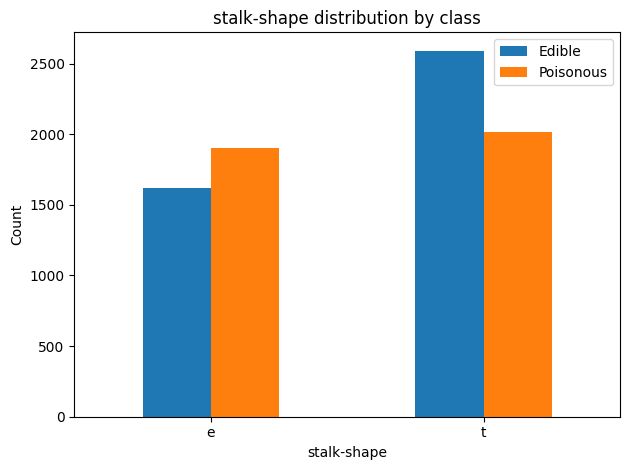

<Figure size 600x400 with 0 Axes>

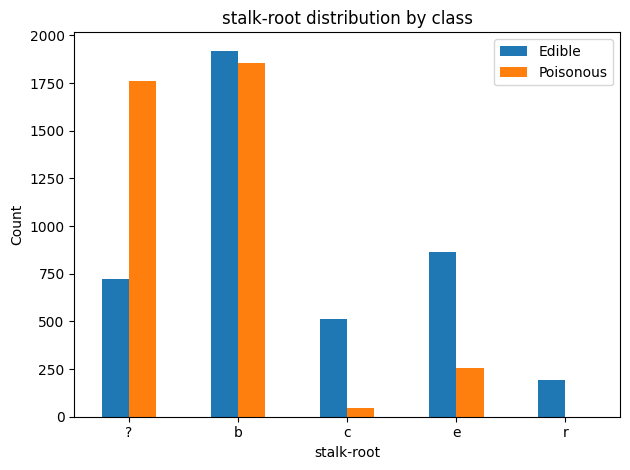

<Figure size 600x400 with 0 Axes>

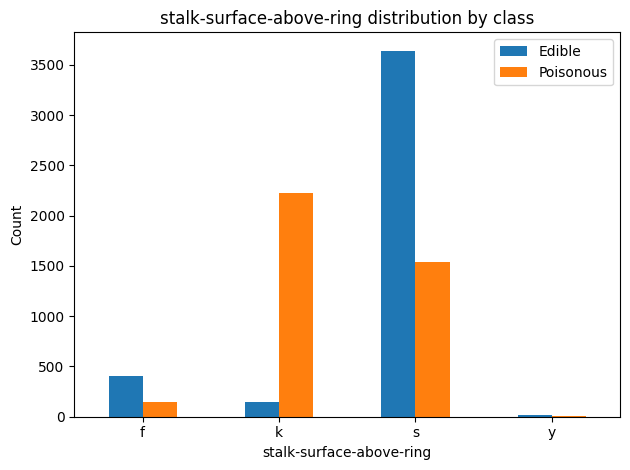

<Figure size 600x400 with 0 Axes>

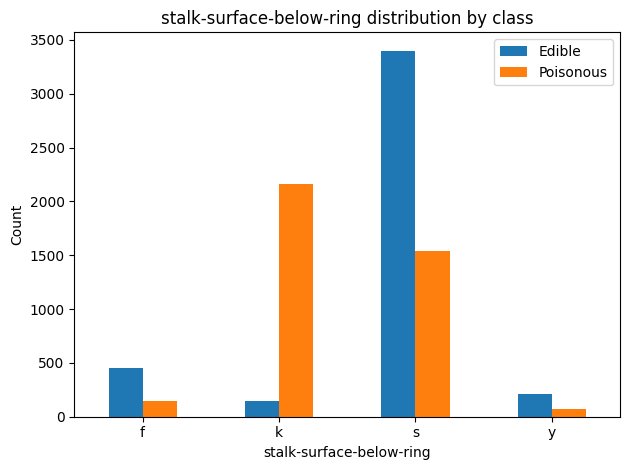

<Figure size 600x400 with 0 Axes>

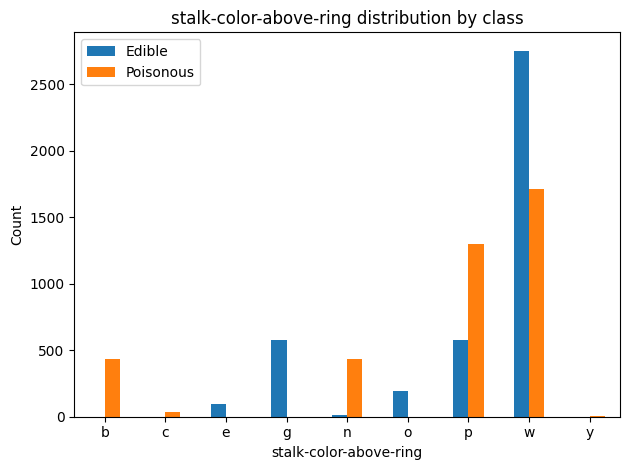

<Figure size 600x400 with 0 Axes>

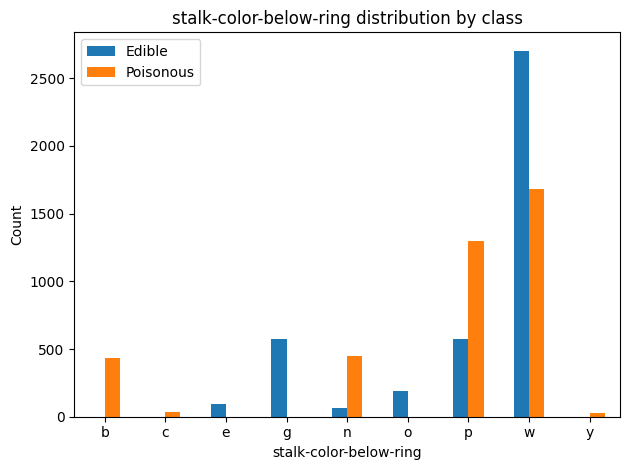

<Figure size 600x400 with 0 Axes>

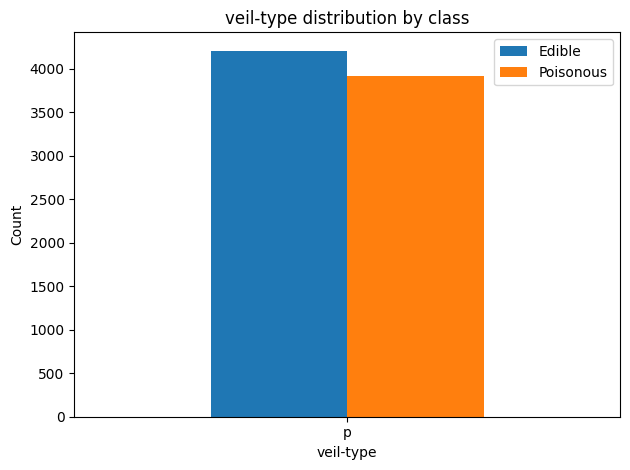

<Figure size 600x400 with 0 Axes>

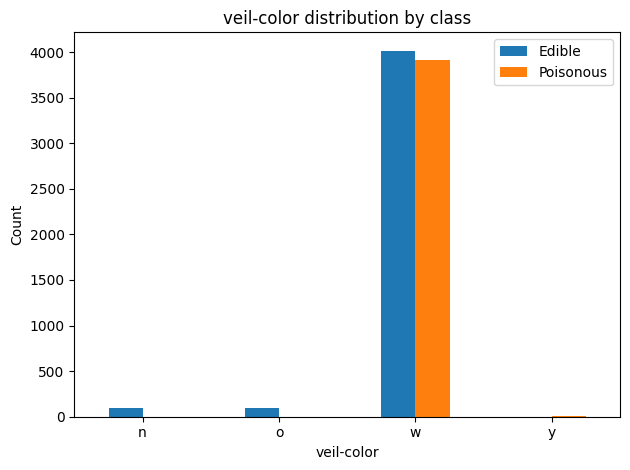

<Figure size 600x400 with 0 Axes>

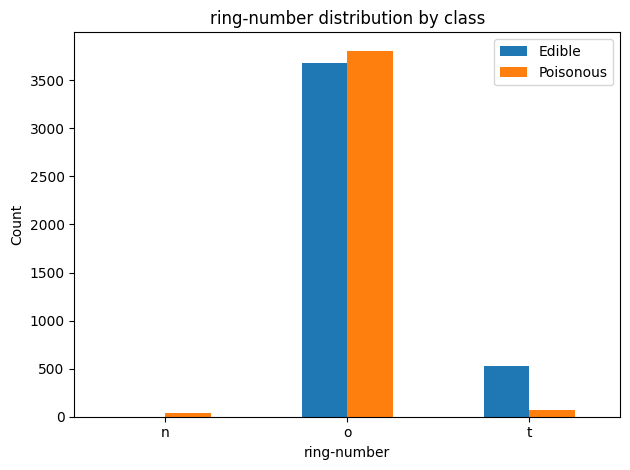

<Figure size 600x400 with 0 Axes>

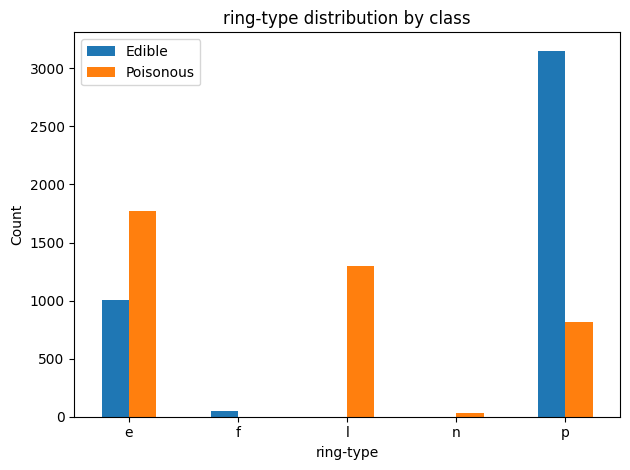

<Figure size 600x400 with 0 Axes>

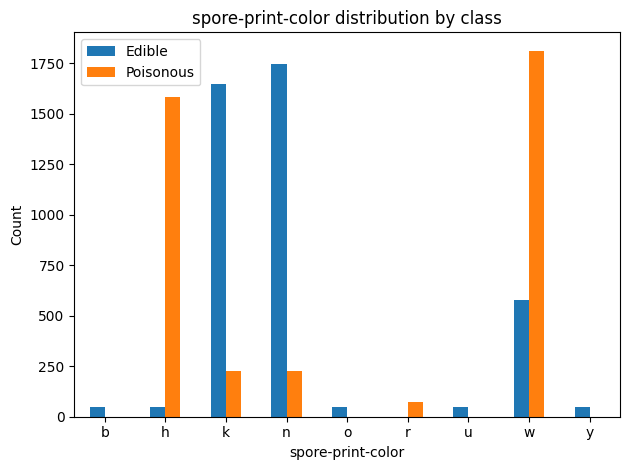

<Figure size 600x400 with 0 Axes>

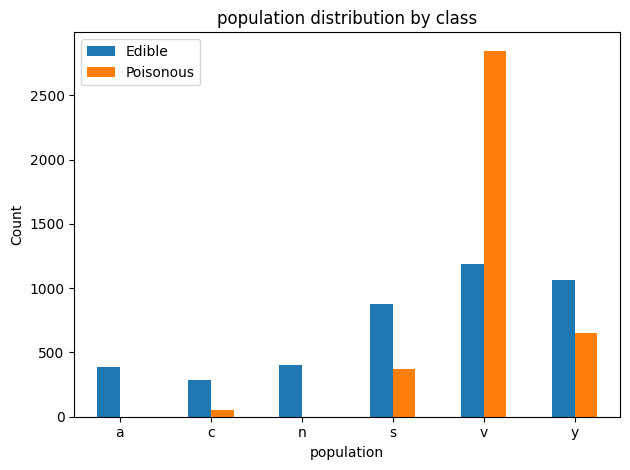

<Figure size 600x400 with 0 Axes>

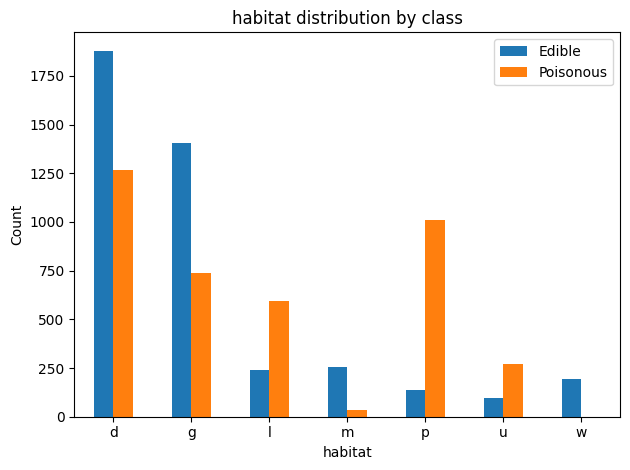

In [6]:
# Loop through each feature
for col in df.columns:
    if col != 'class':
        plt.figure(figsize=(6,4))
        
        # Separate classes
        edible = df[df['class'] == 0][col]
        poisonous = df[df['class'] == 1][col]
        
        # Count values
        edible_counts = edible.value_counts().sort_index()
        poisonous_counts = poisonous.value_counts().sort_index()
        
        # Combine into one table (important for alignment)
        combined = pd.DataFrame({
            'Edible': edible_counts,
            'Poisonous': poisonous_counts
        }).fillna(0)
        
        # Plot
        combined.plot(kind='bar')
        
        plt.title(f"{col} distribution by class")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

## Promising Features for Classification

**Based on the visual distributions by class**:

*   **Odor (`odor`)**: The odor feature shows a strong distinction between edible and poisonous mushrooms. Certain odor types appear in one class, making it a highly indicative feature. For instance, 'a' (almond) and 'l' (anise) odors are only found in edible mushrooms, while 'p' (pungent), 'f' (foul), 'c' (creosote) odors are found in poisonous ones. 'n' (none) odor also shows a clear distribution.
*   **Spore Print Color (`spore-print-color`)**: Similar to odor, different spore print colors are predominantly associated with either edible or poisonous mushrooms, suggesting it's a powerful discriminator.
*   **Gill Size (`gill-size`)**: While not as distinct as odor or spore print color, the distribution of gill size (broad vs. narrow) also shows some differences between the two classes.
*   **Gill Color (`gill-color`)**: Several gill colors are strongly associated with one class over the other, making this a useful feature.
*   **Ring Type (`ring-type`)**: Some ring types are present in one class but absent or very rare in the other, indicating its potential for classification.

These features, where there is clear separation or strong associations between their categories and the 'class' (edible/poisonous), are likely to be most useful for a machine learning model.

## Data Cleaning and Preparation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Data cleaning

In [7]:
# Handle missing values ('?' in stalk-root)
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

# Drop useless column
df = df.drop(columns=['veil-type'])

**Explanation**:
- The '?' in stalk-root was replaced with 'missing' as there is no other data to replace it with.
- 'veil-type' was dropped because it contained only one unique value. As seen in the feature summary, 'veil-type' num unique was 1. When a feature has only one unique value, it means that all the data points have the same value for that feature.

## One-hot encoding

In [8]:
# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

print("New shape after encoding:", df_encoded.shape)

New shape after encoding: (8124, 96)


**Explanation**: One-hot encoding was used because all the features in this dataset are categorical (e.g., 'cap-shape', 'odor', 'gill-color'). Machine learning algorithms, such as Decision Trees, Random Forests, and Logistic Regression, cannot directly process categorical data in its raw string format.

- One-hot encoding converts these categorical variables into a numerical format by creating new binary columns for each unique category within a feature.
- For example, if 'cap-shape' has values 'x', 'b', 's', 'f', 'k', and 'c', it would be converted into six new columns: cap-shape_x, cap-shape_b, cap-shape_s, etc.
- Each of these new columns would contain a 1 if the mushroom has that specific cap shape and a 0 if it does not.

## Rescaling
- Not needed.
- All features are binary after encoding.
- After one-hot encoding, all features become binary (0 or 1), which means they are already on a comparable scale.
- Standard feature scaling techniques like standardization or normalization arenot necessary because they are already on a similar scale.

## Visualization Before/After

In [9]:
# Before
df.iloc[:, :5].head()

# After
df_encoded.iloc[:, :5].head()

,class,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s
0,1,False,False,False,False
1,0,False,False,False,False
2,0,False,False,False,False
3,1,False,False,False,False
4,0,False,False,False,False


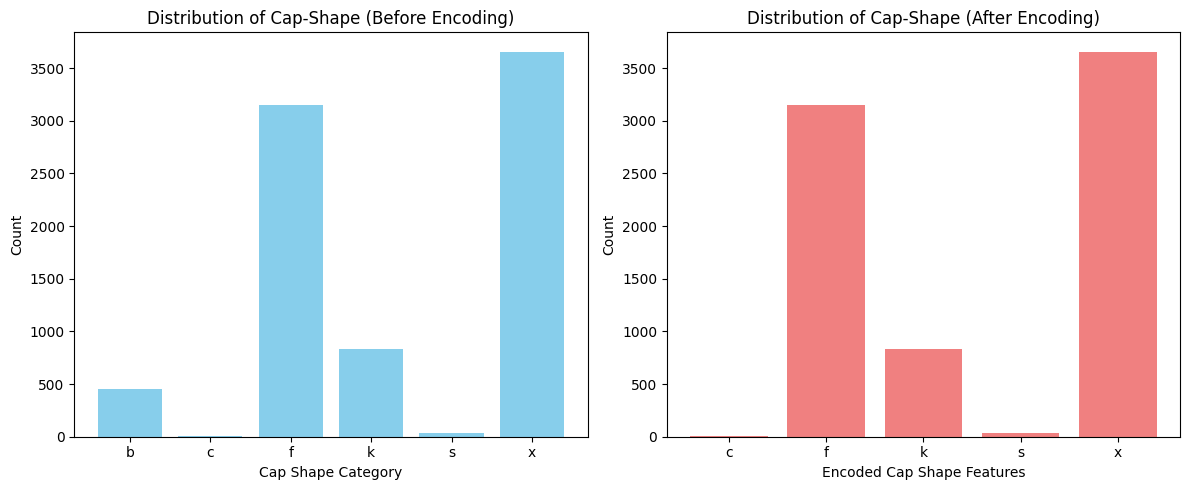

In [10]:
# Visualization for a sample feature: 'cap-shape' 

# Before One-Hot Encoding (Original Categorical Feature)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
cap_shape_counts_before = df['cap-shape'].value_counts().sort_index()
plt.bar(cap_shape_counts_before.index, cap_shape_counts_before.values, color='skyblue')
plt.title('Distribution of Cap-Shape (Before Encoding)')
plt.xlabel('Cap Shape Category')
plt.ylabel('Count')
plt.xticks(rotation=0)

# After One-Hot Encoding (Corresponding Binary Features)
# Select the one-hot encoded columns for 'cap-shape'
cap_shape_cols = [col for col in df_encoded.columns if col.startswith('cap-shape_')]
cap_shape_encoded_counts = df_encoded[cap_shape_cols].sum()

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
# Extract category names for plotting (e.g., 'cap-shape_x' -> 'x')
category_labels = [col.split('_')[-1] for col in cap_shape_encoded_counts.index]
plt.bar(category_labels, cap_shape_encoded_counts.values, color='lightcoral')
plt.title('Distribution of Cap-Shape (After Encoding)')
plt.xlabel('Encoded Cap Shape Features')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


## Problem Formulation: Split training

In [11]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

# Train/Validation/Test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (5686, 95)
Validation size: (1219, 95)
Test size: (1219, 95)


**Explanation**:
- 70% train
- 15% validation
- 15% test

## Train ML Algorithm - Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

**Explanation**:
The Decision Tree was implemented because of its simplicity and interpretability, can handle categorical data, captures non-linear relationships, and serves as a baseline model. 
- Decision Trees are relatively simple to understand and visualize. Their tree-like structure directly mirrors a series of decisions, making it easy to trace how a prediction is made. This interpretability is valuable for understanding the model's logic.
- The mushroom dataset is composed entirely of categorical features. Decision Trees can handle categorical data. The splits are made directly on the categories.
- Decision Trees can effectively capture complex, non-linear relationships and interactions between features, which can be present in many real-world datasets.
- A Decision Tree often serves as a good baseline model. It's quick to train and provides a solid starting point for evaluating the complexity and separability of the dataset. If a simple Decision Tree performs well, it indicates that the problem might not require more complex algorithms.

## Evaluate Decision Tree Performance on Validation Sample

In [13]:
from sklearn.metrics import accuracy_score

# Validation predictions
y_val_pred = model.predict(X_val)

# Accuracy
val_acc = accuracy_score(y_val, y_val_pred)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 1.0


Explanation:
- Accuracy = 1.0 (100%)
- This dataset is very easy to classify

## Feature Importance Analysis for Decision Tree

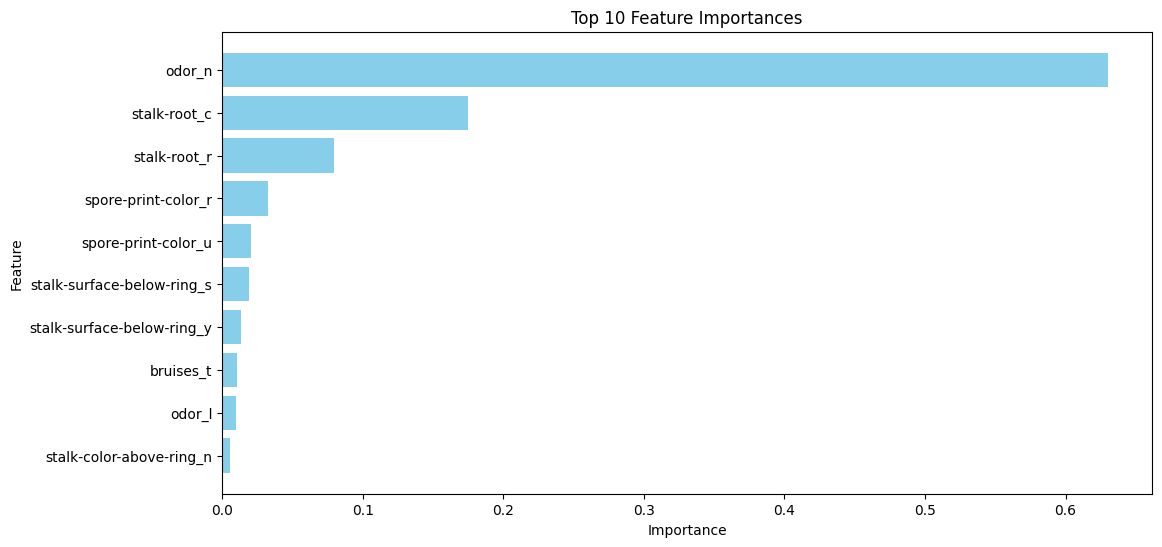

In [14]:
# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot the top N features (e.g., top 10)
plt.figure(figsize=(12, 6))
plt.barh(features_df['Feature'].head(10), features_df['Importance'].head(10), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis() # To have the most important feature at the top
plt.show()

**Interpretation of the Feature Importance graph**:

- Based on the lengths of the bars, odor (odor_n) is displayed as the most important feature. This aligns with our initial data exploration which suggested 'odor' as a strong discriminator.
- Features like stalk-root_c, stalk-root_r, spore-print-color_r, and spore-print-color_u also show significant importance. This suggests that the characteristics related to the mushroom's stalk root and spore print color are also highly predictive of whether a mushroom is edible or poisonous.

## Decision Tree Visualization

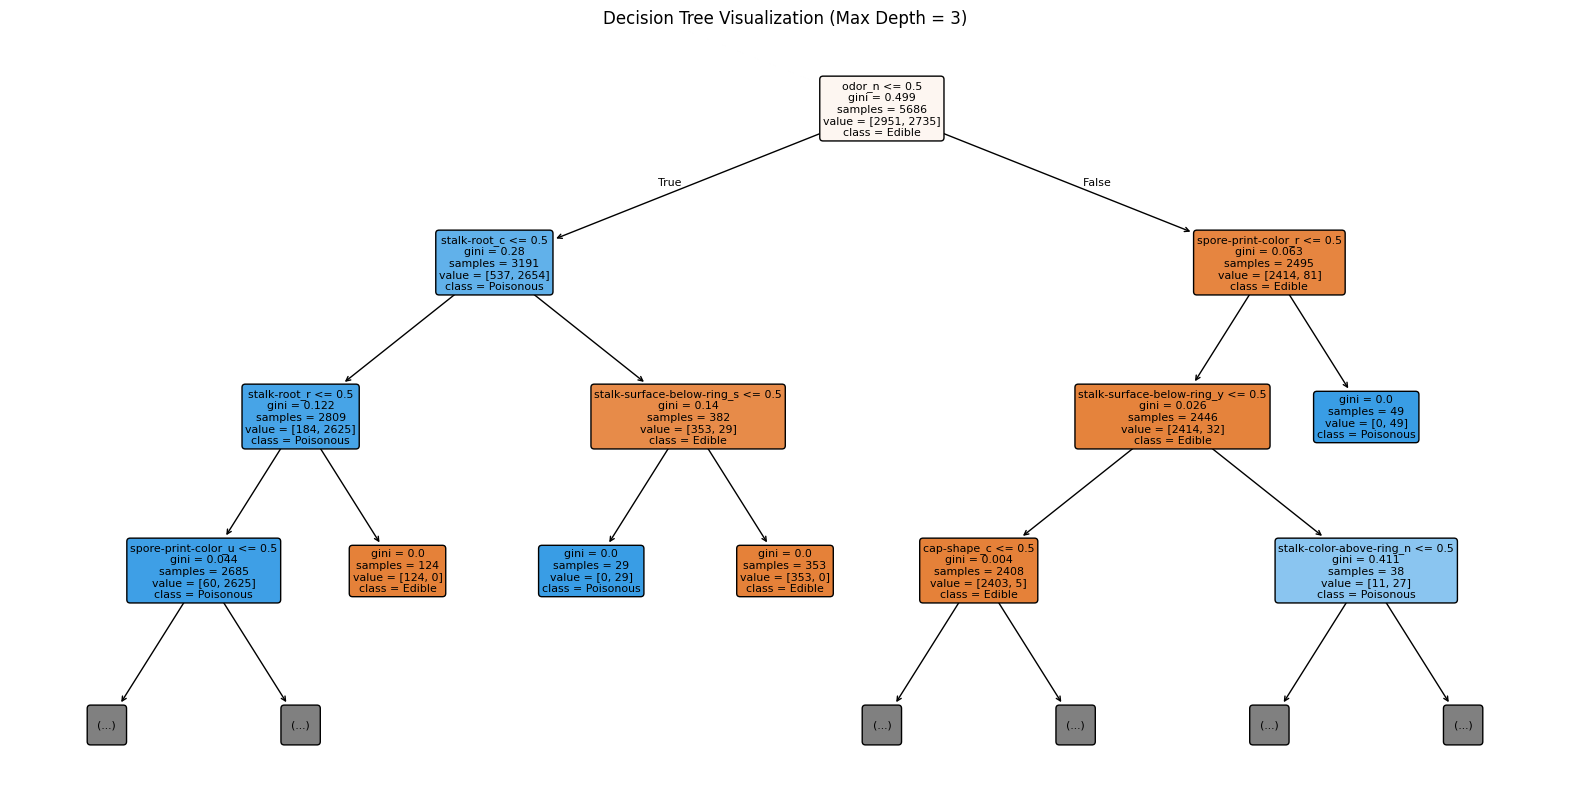

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) 
plot_tree(model, 
          feature_names=X_train.columns,
          class_names=['Edible', 'Poisonous'],
          filled=True, 
          rounded=True,
          max_depth=3) # Limit depth for clarity, or remove for full tree
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()

**Interpretation of the Decision Tree Visualization:**

This visualization displays the first few levels (`max_depth=3`) of the Decision Tree. Each node in the tree represents a decision rule based on a feature, leading to subsequent nodes or a final classification (leaf node).

*   **Nodes:** Each node shows:
    *   The feature and threshold used for splitting (e.g., `odor_n <= 0.5`).
    *   `gini`: The Gini impurity (a measure of node impurity). A `gini` of 0 means the node is pure (all samples belong to one class).
    *   `samples`: The number of training samples at that node.
    *   `value`: The number of samples per class at that node (e.g., `[edible_count, poisonous_count]`).
    *   `class`: The predicted class for the majority of samples in that node.
*   **Colors:** The color of the node indicates the majority class within that node. The color intensity indicates node purity.

From the visualization, you can see how the model uses features like `odor_n` (odor_none), `stalk-root_c` (stalk-root_club), and `stalk-root_r` (stalk-root_rooted) at the top levels to make its decisions. This separates the majority of samples into their correct classes. This aligns with the feature importance plot, showing these features as highly discriminative.

## Confusion Matrix for Decision Tree

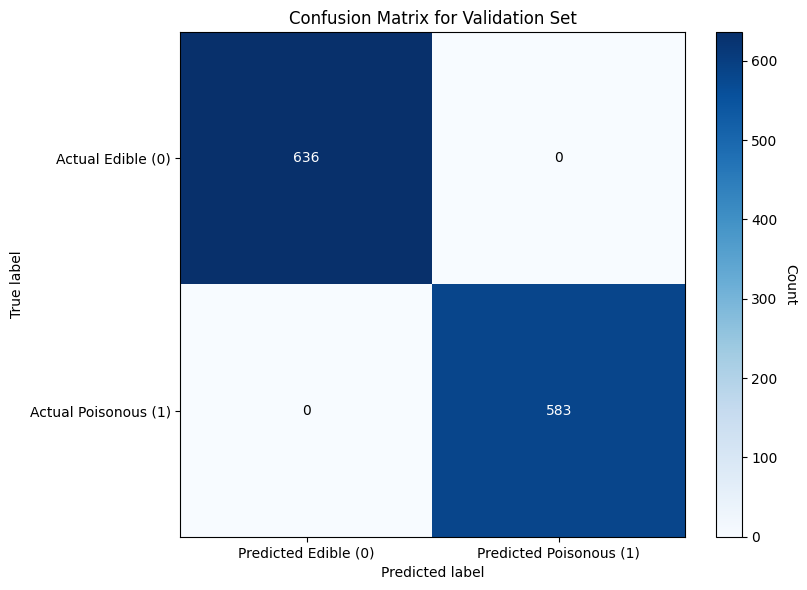

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the confusion matrix for the validation set
cm = confusion_matrix(y_val, y_val_pred)

# Plotting the confusion matrix using matplotlib only
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Count', rotation=-90, va='bottom')

# Set labels and title
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Predicted Edible (0)', 'Predicted Poisonous (1)'],
       yticklabels=['Actual Edible (0)', 'Actual Poisonous (1)'],
       title='Confusion Matrix for Validation Set',
       ylabel='True label',
       xlabel='Predicted label')

# Loop over data dimensions and create text annotations.
fmt = 'd' # format for integers
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], fmt),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
fig.tight_layout()
plt.show()

**Explanation**: The confusion matrix further confirms the perfect performance of the Decision Tree model on the validation set, showing zero false positives and zero false negatives.

The confusion matrix shows us these things:
- True Positives (TP): Poisonous mushrooms correctly identified as poisonous.
- True Negatives (TN): Edible mushrooms correctly identified as edible.
- False Positives (FP): Edible mushrooms incorrectly identified as poisonous (Type I error).
- False Negatives (FN): Poisonous mushrooms incorrectly identified as edible (Type II error).

The confusion matrix visually confirms the 100% Decision Tree accuracy by showing high numbers in the True Positive and True Negative cells, and zero (or very close to zero) in the False Positive and False Negative cells. This explicitly demonstrates that the model is making no errors on the validation set.

**Interpretation of the confusion matrix**:

- 636 represents the True Negatives (TN). It means that 636 edible mushrooms were correctly classified by the model as edible.
- 583 represents the True Positives (TP). It means that 583 poisonous mushrooms were correctly classified by the model as poisonous.

## Train ML Algorithm - Random Forest (for comparison)

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Explanation**: Random Forest was implemented because of its ensemble learning, reduced overfitting, and increased robustness and generalization.

- Random Forest is an ensemble learning method that builds multiple decision trees during training and outputs the mode of the classes (for classification). This collective decision-making often leads to more stable and reliable predictions.
- A single Decision Tree can be prone to overfitting. This creates complex rules that perfectly fit the training data but generalize poorly to new, unseen data. Random Forest mitigates this by averaging out the biases and variances of individual trees.
- Even if a dataset appears 'easy' for a single Decision Tree, using a Random Forest provides a more robust model that is less sensitive to small changes in the training data. This makes it a stronger choice for real-world scenarios where data might be less clean or have more variability.

## Evaluate Random Forest Performance on Validation Sample

In [18]:
from sklearn.metrics import accuracy_score

# Validation predictions for Random Forest
y_val_pred_rf = rf_model.predict(X_val)

# Accuracy for Random Forest
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
print("Random Forest Validation Accuracy:", val_acc_rf)

print("\nDecision Tree Validation Accuracy:", val_acc)

Random Forest Validation Accuracy: 1.0

Decision Tree Validation Accuracy: 1.0


**Comparison between Decision Tree and Random Forest**:

Both the Decision Tree and Random Forest models achieved a perfect 1.0 (100%) accuracy on the validation set for this dataset. This reinforces that the dataset is highly separable and relatively easy to classify with these tree-based models. While Random Forest is generally more robust and less prone to overfitting than a single Decision Tree, in this case, the simplicity of the underlying patterns allows the Decision Tree to perform perfectly.

## Train ML Algorithm - Logistic Regression (for comparison)

In [19]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a Logistic Regression Classifier
# Setting max_iter to avoid convergence warning on some datasets
lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**Explanation**: Logistic Regression was implemented to test a linear model, assess dataset separability, understanding model strengths, and interpretability.

- Logistic Regression, being a linear classification algorithm, offers a contrast to the non-linear Decision Tree and Random Forest models. This comparison helps in understanding the inherent linearity or non-linearity of the problem.
- By testing a linear model, you can gauge how 'linearly separable' the dataset is. If a linear model performs very well, it indicates that the classes can be mostly separated by a hyperplane, even if tree-based models find slightly more complex, perfect boundaries.
- The slight difference in accuracy (0.999 for Logistic Regression vs. 1.0 for tree models) highlights that while the dataset is almost perfectly separable linearly, the non-linear approaches were able to capture those final, subtle distinctions that led to perfect classification.
- While Decision Trees offer interpretability through rules, Logistic Regression offers interpretability through feature coefficients, which indicate the strength and direction of the relationship between each feature and the log-odds of the target variable. This provides a different perspective on feature impact.

## Evaluate Logistic Regression Performance on Validation Sample

In [20]:
from sklearn.metrics import accuracy_score

# Validation predictions for Logistic Regression
y_val_pred_lr = lr_model.predict(X_val)

# Accuracy for Logistic Regression
val_acc_lr = accuracy_score(y_val, y_val_pred_lr)
print("Logistic Regression Validation Accuracy:", val_acc_lr)

print("\nDecision Tree Validation Accuracy:", val_acc)
print("Random Forest Validation Accuracy:", val_acc_rf)

Logistic Regression Validation Accuracy: 0.9991796554552912

Decision Tree Validation Accuracy: 1.0
Random Forest Validation Accuracy: 1.0


**Comparison of Decision Tree and Random Forest with Logistic Regression**:

The Logistic Regression model achieved a validation accuracy of approximately 0.999. While extremely high, this is slightly less than the perfect 1.0 (100%) accuracy from the Decision Tree and Random Forest models on this dataset. This indicates that while the mushroom dataset is highly separable, the linear decision boundary of Logistic Regression might not capture every subtle distinction as precisely as the non-linear, tree-based models. Despite this minor difference, the consistent high performance across all three model types still highlights the straightforward characteristics of this dataset for classification.

## Apply ML to the challenge test set

In [21]:
from sklearn.metrics import accuracy_score

# Test predictions for Decision Tree
y_test_pred = model.predict(X_test)

# Accuracy for Decision Tree
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 1.0


In [22]:
# Test predictions for Random Forest
y_test_pred_rf = rf_model.predict(X_test)

# Accuracy for Random Forest
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)
print("Random Forest Test Accuracy:", test_acc_rf)

Random Forest Test Accuracy: 1.0


In [23]:
# Test predictions for Logistic Regression
y_test_pred_lr = lr_model.predict(X_test)

# Accuracy for Logistic Regression
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
print("Logistic Regression Test Accuracy:", test_acc_lr)

Logistic Regression Test Accuracy: 0.9991796554552912


**Overall Test Accuracy Comparison:**

- **Decision Tree Test Accuracy:** 1.0
- **Random Forest Test Accuracy:** 1.0
- **Logistic Regression Test Accuracy:** 0.9991796554552912

All three models performed well on the test set, with the Decision Tree and Random Forest achieving perfect accuracy. This indicates that the Decision Tree and Random Forest model classified all mushrooms in the test set as either edible or poisonous. The Logistic Regression model also shows very strong performance, indicating the dataset is highly separable. This confirms the robustness of the findings from the validation set evaluation.

## Generate the submission file

In [24]:
# Create a DataFrame for submission
submission_df = pd.DataFrame({
    'id': X_test.index, # Using original DataFrame index as 'id'
    'class': y_test_pred # Predictions from the Decision Tree model
})

# (Assuming 0 is 'e' and 1 is 'p' based on earlier encoding)
submission_df['class'] = submission_df['class'].map({0: 'e', 1: 'p'})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")
print(submission_df.head())

Submission file 'submission.csv' created successfully!
     id class
0  5375     p
1  2966     e
2  6574     p
3  7828     e
4  4374     p
